# 01 — Selección de clases y splits

Hito **H2** del proyecto ABP.

Este notebook documenta:

1. Las **20 clases finales** que se usan en el resto del proyecto, agrupadas por su función comparativa Clásico vs DL.
2. La **construcción de los splits** train/val/test definitivos en `data/processed/`.
3. **Estadísticas por clase y split** tras el filtrado.
4. **Visualización** de escenas de test cluttered (caso de uso real del proyecto).

**Requisito previo**: haber ejecutado:

```powershell
uv run python scripts/prepare_splits.py
```

que produce los 3 JSONs en `data/processed/`.

In [2]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
repo_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
sys.path.insert(0, str(repo_root / "src"))

from grocery_detection.utils.config import load_yaml
from grocery_detection.data.eda import (
    load_coco,
    count_instances_per_class,
    count_images_per_class,
    flatten_target_classes,
)

data_cfg = load_yaml(repo_root / "configs" / "data.yaml")
classes_cfg = load_yaml(repo_root / "configs" / "classes.yaml")

split_paths = {
    name: repo_root / rel for name, rel in data_cfg["filtered_splits"].items()
}
img_dir = repo_root / data_cfg["paths"]["d2s_images"]

for name, p in split_paths.items():
    print(f"  {name:5s} → {p}  (existe={p.exists()})")

missing = [name for name, p in split_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"Splits ausentes: {missing}. Ejecuta primero: "
        "uv run python scripts/prepare_splits.py"
    )

  train → C:\Users\artur\Desktop\VC-ABP\GroceryTracker\data\processed\train.json  (existe=True)
  val   → C:\Users\artur\Desktop\VC-ABP\GroceryTracker\data\processed\val.json  (existe=True)
  test  → C:\Users\artur\Desktop\VC-ABP\GroceryTracker\data\processed\test.json  (existe=True)


## 1. Criterios de selección de las 20 clases

MVTec D2S contiene 60 SKUs en total. Tras la verificación de H1, se filtra a **20 clases** siguiendo tres criterios:

**A. Mercadona-defensible.** Todos los productos seleccionados están disponibles en Mercadona España (manzanas, pasta Reggia, Coca-Cola, barritas Corny, uvas, tomates, clementinas, zanahoria, pepino, kiwi). Se descartan los productos D2S que son nicho alemán (aguas Adelholzener, cervezas Augustiner/Tegernseer, cafés/tés GEPA, muesli Kölln/Dr. Oetker, tinta Pelikan).

**B. Triadas y pares confusables.** El valor académico del proyecto vive en las distinciones fine-grained — donde el pipeline clásico (HOG+BoVW+SVM) puede fallar y YOLO debería triunfar. Cada grupo de clases comparte forma o packaging y se diferencia por un atributo sutil:

| Grupo | Clases | Eje de diferencia | Hipótesis Clásico vs DL |
|---|---|---|---|
| **Manzanas** | 4 | Variedad (color, textura sutil) | HOG inútil (misma silueta), BoVW dudoso, YOLO debería distinguir |
| **Pasta Reggia** | 3 | Forma interior, mismo packaging azul | Test de detalle fino a través del plástico |
| **Coca-Cola** | 2 | Color de lata (rojo vs plata) | Test de discriminación de color |
| **Corny** | 2 | Sabor (envoltorio similar) | Test de lectura de etiqueta |
| **Uvas** | 2 | Color (verde vs morada) | Test de color/textura |
| **Tomates** | 2 | Variante (vine vs roma-vine) | Test fine-grained |
| **Clementinas** | 2 | Presentación (malla vs suelta) | Test de pose/composición |
| **Singletons** | 3 | — | Diversidad de forma (zanahoria, pepino, kiwi) |

**C. Muestras suficientes.** Cada clase debe tener ≥60 instancias en train y ≥60 en test. Verificado contra D2S en H1.

El plan original (sesión anterior) proponía Kellogg's / Mars / Snickers / Haribo / Red Bull — **ninguna de esas clases existe en D2S**, lo que invalidó el plan. Esta revisión sustituye a aquella lista y mantiene intacto el objetivo académico (comparativa fine-grained).

In [3]:
print(f"Las {sum(len(g['items']) for g in classes_cfg['target_classes'])} clases finales:\n")
for group in classes_cfg["target_classes"]:
    print(f"[{group['group']}]")
    for item in group["items"]:
        print(f"   - {item}")
    print()

Las 20 clases finales:

[apples]
   - apple_braeburn_bundle
   - apple_golden_delicious
   - apple_granny_smith
   - apple_red_boskoop

[pasta_reggia]
   - pasta_reggia_elicoidali
   - pasta_reggia_fusilli
   - pasta_reggia_spaghetti

[coca_cola]
   - coca_cola_05
   - coca_cola_light_05

[corny]
   - corny_nussvoll
   - corny_schoko_banane

[grapes]
   - grapes_green_sugraone_seedless
   - grapes_sweet_celebration_seedless

[tomatoes]
   - vine_tomatoes
   - roma_vine_tomatoes

[clementines]
   - clementine
   - clementine_single

[produce]
   - carrot
   - cucumber
   - kiwi



## 2. Construcción de los splits

MVTec D2S trae 2 splits anotados (`D2S_training.json`, `D2S_validation.json`) y **ninguno llamado test** con ground truth. Para tener un set de test cluttered con anotaciones, se separa `D2S_validation` en val + test estratificado por clase dominante.

**Decisiones**:

1. **train** = `D2S_training` filtrado a las 20 clases. Cada imagen contiene 1 producto sobre fondo blanco/uniforme ("catálogo").
2. **val + test** = `D2S_validation` filtrado, split estratificado **30% val / 70% test** por la *clase dominante* de cada imagen (la clase con más instancias en esa imagen).
3. Test recibe el 70% para tener ≥60 instancias por clase (mínimo del proyecto) y un set de evaluación grande y representativo.
4. Val recibe el 30%, suficiente para *early stopping* de YOLO. Algunas clases bajan a ~30 instancias en val — irrelevante para esta función.
5. Semilla fija (42) para reproducibilidad. Re-ejecutar `prepare_splits.py` produce exactamente los mismos splits.
6. IDs de categoría renumerados a 1..20 (orden de `classes.yaml`). Esto simplifica la conversión a formato YOLO en H6.

**Por qué "clase dominante" y no estratificación multi-label**: las imágenes test de D2S contienen múltiples productos. Estratificar por todas las etiquetas presentes es un problema NP-hard. Usar la clase con más instancias es una heurística simple que en la práctica reparte cada clase de forma equilibrada (verificable en la tabla siguiente).

In [4]:
splits = {name: load_coco(p) for name, p in split_paths.items()}
for name, coco in splits.items():
    print(f"{name:5s}: {len(coco['images']):4d} imgs   {len(coco['annotations']):5d} anns   {len(coco['categories'])} clases")

train: 1650 imgs    2130 anns   20 clases
val  :  603 imgs    1476 anns   20 clases
test : 1407 imgs    3377 anns   20 clases


## 3. Estadísticas por clase y split

In [5]:
import pandas as pd

targets = flatten_target_classes(classes_cfg)
rows = []
for name in targets:
    row = {"class": name}
    for split_name, coco in splits.items():
        inst = count_instances_per_class(coco)
        imgs = count_images_per_class(coco)
        row[f"{split_name}_inst"] = inst.get(name, 0)
        row[f"{split_name}_img"] = imgs.get(name, 0)
    rows.append(row)

df = pd.DataFrame(rows).set_index("class")
df.loc["TOTAL"] = df.sum(numeric_only=True)
df

,train_inst,train_img,val_inst,val_img,test_inst,test_img
class,,,,,,
apple_braeburn_bundle,60,60,64,64,146,146
apple_golden_delicious,90,30,83,73,187,167
apple_granny_smith,90,30,56,47,124,103
apple_red_boskoop,180,60,119,65,241,145
pasta_reggia_elicoidali,120,120,27,27,63,63
pasta_reggia_fusilli,120,120,96,96,234,234
pasta_reggia_spaghetti,90,90,62,62,148,148
coca_cola_05,60,30,39,39,81,81
coca_cola_light_05,150,60,85,73,185,167


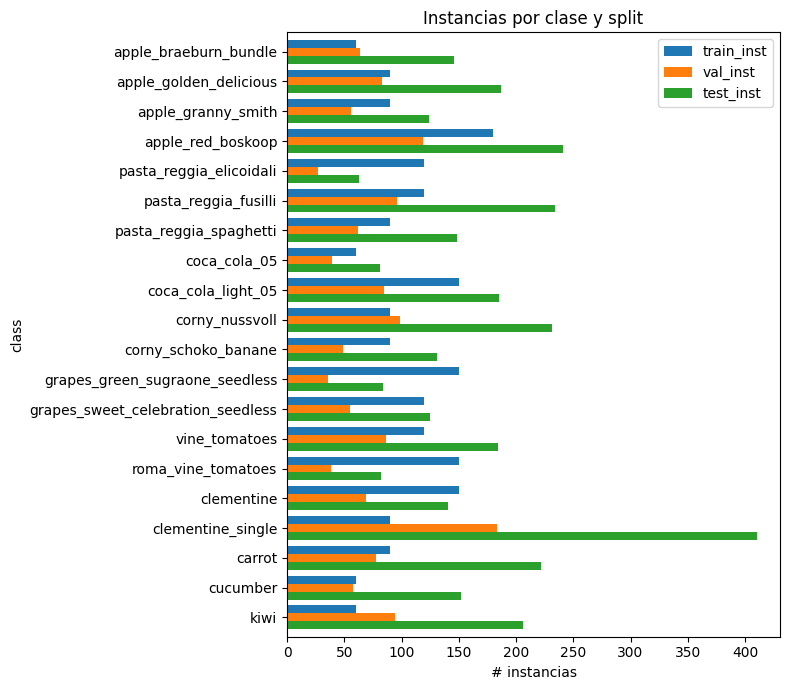

In [6]:
import matplotlib.pyplot as plt

plot_df = df.drop("TOTAL")[["train_inst", "val_inst", "test_inst"]]
ax = plot_df.plot.barh(figsize=(8, 7), stacked=False, width=0.8)
ax.set_xlabel("# instancias")
ax.set_title("Instancias por clase y split")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Visualización de escenas test (cluttered)

El train de D2S es "catálogo" (un producto sobre fondo blanco). El **test** son **escenas cluttered con múltiples productos** — el caso de uso real del proyecto y donde se ve la diferencia entre Clásico y DL.

Mostramos 6 imágenes aleatorias del test con todas las bboxes dibujadas, una por instancia.

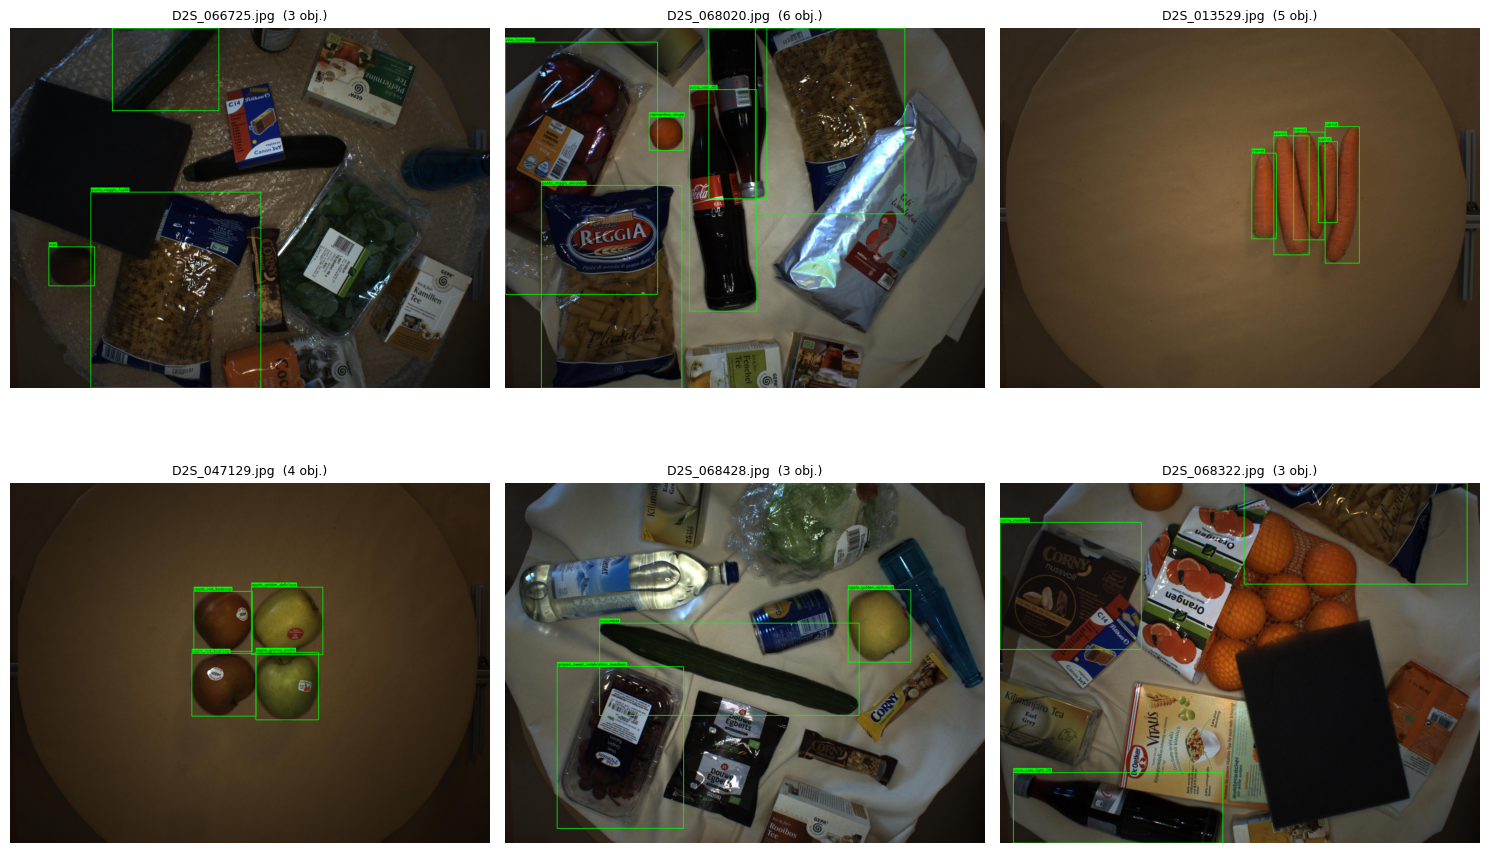

In [7]:
import random
import cv2
from grocery_detection.data.visualize import draw_bbox

random.seed(0)
test_coco = splits["test"]
id_to_img = {im["id"]: im for im in test_coco["images"]}
id_to_name = {c["id"]: c["name"] for c in test_coco["categories"]}

anns_by_img: dict[int, list[dict]] = {}
for a in test_coco["annotations"]:
    anns_by_img.setdefault(a["image_id"], []).append(a)

# Elegir 6 imágenes con al menos 3 instancias (escenas cluttered de verdad)
candidates = [iid for iid, anns in anns_by_img.items() if len(anns) >= 3]
sample_ids = random.sample(candidates, min(6, len(candidates)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, iid in zip(axes.flat, sample_ids):
    info = id_to_img[iid]
    img_path = img_dir / info["file_name"]
    if not img_path.exists():
        ax.set_title(f"{info['file_name']} (no encontrada)", fontsize=8)
        ax.axis("off")
        continue
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for a in anns_by_img[iid]:
        x, y, w, h = a["bbox"]
        draw_bbox(img, x, y, w, h, label=id_to_name[a["category_id"]])
    ax.imshow(img)
    ax.set_title(f"{info['file_name']}  ({len(anns_by_img[iid])} obj.)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Resumen H2

**Cerrado:**

- 20 clases finales en `configs/classes.yaml`, todas verificadas contra D2S.
- Splits filtrados generados con `scripts/prepare_splits.py`:
  - `data/processed/train.json` — catálogo (un objeto por imagen).
  - `data/processed/val.json` — escenas cluttered (30% de D2S val).
  - `data/processed/test.json` — escenas cluttered (70% de D2S val).
- IDs de categoría renumerados a 1..20 (orden de `classes.yaml`).
- Split reproducible (seed=42).

**Pasamos a H3**: pipeline clásico — Selective Search + HOG + BoVW. Primer bloque a tocar: `src/grocery_detection/classical/proposals.py`.